In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/business_slotting_recommendations.csv"
)

df.head()

,StockCode,order_frequency,total_quantity,avg_quantity_per_order,related_product_count,cluster_name,recommended_zone,distance_from_packing,picking_priority,current_distance,distance_saved,business_recommendation
0,85099B,2089,48371,22.935514,3513,High-Volume Products,Zone A,10.0,101047019,60,50.0,Place in Zone A based on product movement and ...
1,85123A,2198,37641,16.707057,3562,High-Volume Products,Zone A,10.0,82734918,60,50.0,Place in Zone A based on product movement and ...
2,22197,1392,56898,40.125529,3545,High-Volume Products,Zone A,10.0,79202016,60,50.0,Place in Zone A based on product movement and ...
3,84879,1455,36362,24.635501,3351,High-Volume Products,Zone A,10.0,52906710,60,50.0,Place in Zone A based on product movement and ...
4,21212,1320,36396,26.920118,3438,High-Volume Products,Zone A,10.0,48042720,60,50.0,Place in Zone A based on product movement and ...


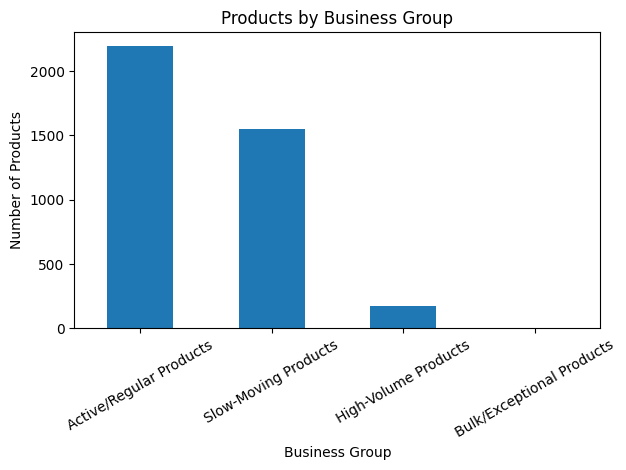

In [2]:
cluster_counts = df["cluster_name"].value_counts()

cluster_counts.plot(kind="bar")

plt.title("Products by Business Group")
plt.xlabel("Business Group")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

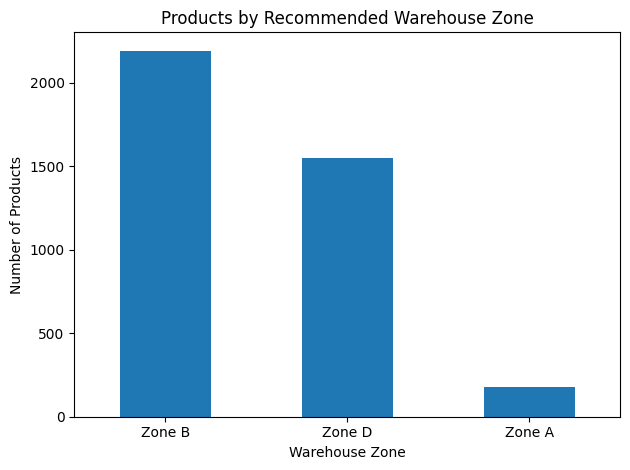

In [3]:
zone_counts = df["recommended_zone"].value_counts()

zone_counts.plot(kind="bar")

plt.title("Products by Recommended Warehouse Zone")
plt.xlabel("Warehouse Zone")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

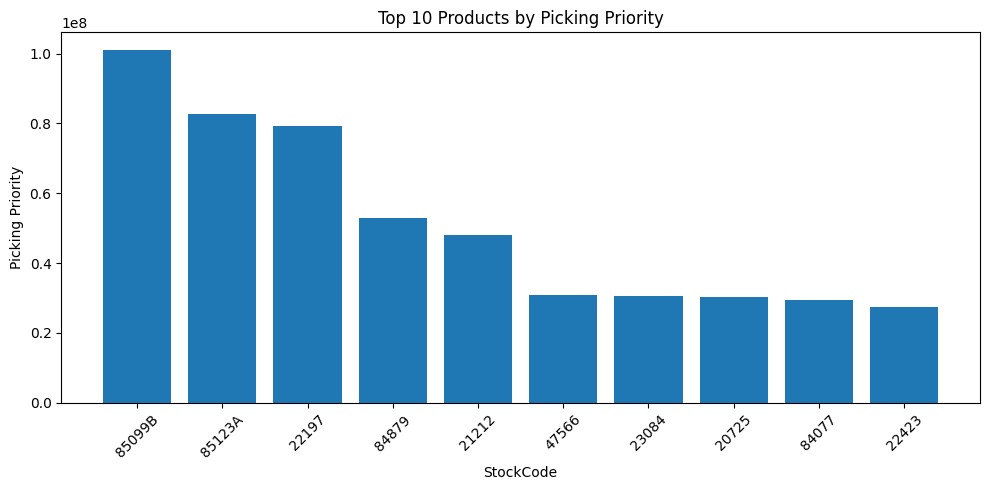

In [4]:
top_10 = df.sort_values(
    "picking_priority",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_10["StockCode"].astype(str),
    top_10["picking_priority"]
)

plt.title("Top 10 Products by Picking Priority")
plt.xlabel("StockCode")
plt.ylabel("Picking Priority")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

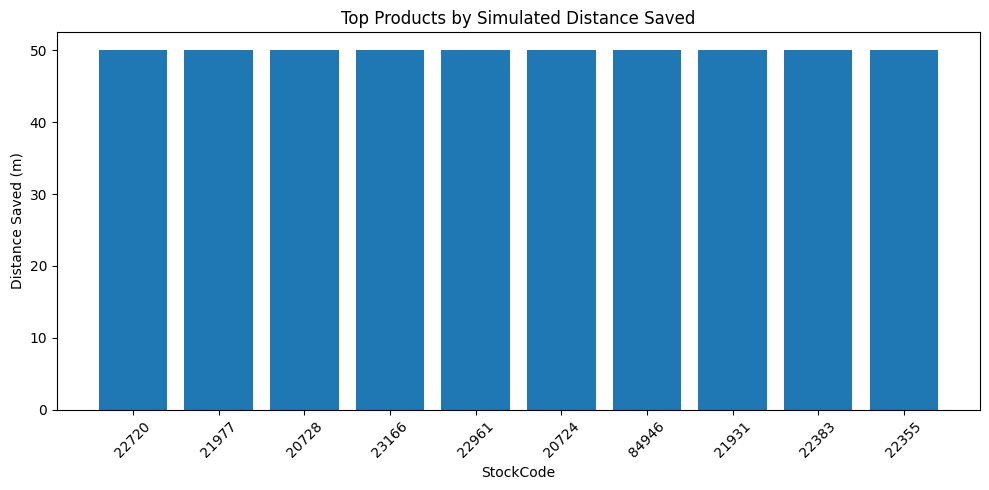

In [5]:
plt.figure(figsize=(10, 5))

top_distance = df.sort_values(
    "distance_saved",
    ascending=False
).head(10)

plt.bar(
    top_distance["StockCode"].astype(str),
    top_distance["distance_saved"]
)

plt.title("Top Products by Simulated Distance Saved")
plt.xlabel("StockCode")
plt.ylabel("Distance Saved (m)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
print("Total Products:", len(df))

print(
    "High-Volume Products:",
    (df["cluster_name"] == "High-Volume Products").sum()
)

print(
    "Products in Zone A:",
    (df["recommended_zone"] == "Zone A").sum()
)

print(
    "Average Distance Saved:",
    round(df["distance_saved"].mean(), 2),
    "m"
)

Total Products: 3922
High-Volume Products: 178
Products in Zone A: 178
Average Distance Saved: 21.84 m


In [7]:
df.to_csv(
    "../data/processed/dashboard_data.csv",
    index=False
)